In [2]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [3]:
# ==============================================================================
# CELL 1: OPERACIÓN FUSIÓN (SIN HACK DE DRIVER)
# ==============================================================================
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine

display(Markdown("### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**"))

# --- 1. CONFIGURACIÓN ---
KML_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/Poligonos_beta.kml' # <-- ¡VERIFICA ESTA RUTA!
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

# --- 2. CARGA DE ACTIVOS ---
try:
    # --- LA CORRECCIÓN CLAVE: Eliminamos la línea del driver ---

    # Cargar los polígonos
    gdf_zonas = gpd.read_file(KML_PATH, driver='KML')
    gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})[['zone_name', 'geometry']]
    print(f"✅ {len(gdf_zonas)} polígonos cargados desde KML.")

    # Cargar los puntos de dropoff
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    query_points = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_points = pd.read_sql(query_points, db_engine)
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )
    print(f"✅ {len(gdf_points)} puntos de dropoff cargados.")

    # --- 3. LA FUSIÓN GEOESPACIAL ---
    print("\n⏳ Ejecutando `Point-in-Polygon` (sjoin)...")
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')

    gdf_merged = gdf_merged.drop_duplicates(subset='offer_id', keep='first').drop(columns=['index_right'])
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    print("✅ Asignación completada.")

    # --- 4. PREVIEW Y AUDITORÍA ---
    display(Markdown("\n### 📊 **Censo Preliminar de Zonas**"))
    zone_counts = gdf_merged['zone_name'].value_counts().reset_index()
    zone_counts.columns = ['Zone Name', 'Offer Count']
    display(zone_counts)

    df_final_zones = gdf_merged[['offer_id', 'zone_name']]

    # --- 5. GUARDA EL RESULTADO ---
    output_csv_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv'
    df_final_zones.to_csv(output_csv_path, index=False)
    display(Markdown(f"\n✅ **¡VICTORIA!** El mapa de zonas ha sido guardado en: `{output_csv_path}`"))

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")
    print("\n💡 SUGERENCIA: Asegúrate de que el archivo KML no esté corrupto y que la ruta sea correcta.")

### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**

✅ 69 polígonos cargados desde KML.
✅ 4760 puntos de dropoff cargados.

⏳ Ejecutando `Point-in-Polygon` (sjoin)...
✅ Asignación completada.



### 📊 **Censo Preliminar de Zonas**

,Zone Name,Offer Count
0,EXTERIOR / VETO,2370
1,Proxy,188
2,Santa Fe Alto,169
3,Santa Fe_Medio,150
4,Carso/Antara/Miyana,122
...,...,...
65,Tecamachalco,7
66,El Olivo,5
67,Club de Golf Lomas,3
68,Olimpo,2



✅ **¡VICTORIA!** El mapa de zonas ha sido guardado en: `/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv`

In [4]:
# ==============================================================================
# CELL: ANÁLISIS ECONÓMICO POR ZONA (UPFRONT FARE)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ASUNCIÓN: `gdf_merged` (con `offer_id` y `zone_name`) y `df_master` (con `upfront_fare`) existen.
# Vamos a reconstruirlo de forma segura.

display(Markdown("### 💰 **Análisis Económico: Tarifa Promedio (`upfront_fare`) por Zona**"))

# --- 1. PREPARACIÓN ---
# Cargar datos de tarifa
query_fares = "SELECT offer_id, upfront_fare FROM offers"
df_fares = pd.read_sql(query_fares, db_engine)
df_fares.columns = df_fares.columns.str.lower()

# Cargar los resultados de la asignación de zonas (el CSV que guardamos)
try:
    zones_csv_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv'
    df_zones = pd.read_csv(zones_csv_path)
    print(f"✅ Archivo de zonas '{zones_csv_path}' cargado.")

    # Unir la información de tarifas con la de zonas
    df_econ_geo = pd.merge(df_fares, df_zones, on='offer_id', how='inner')

    # --- 2. CÁLCULO ---
    # Agrupar por zona y calcular el promedio y el tamaño
    zone_economics = df_econ_geo.groupby('zone_name')['upfront_fare'].agg(['mean', 'count']).reset_index()
    zone_economics = zone_economics.rename(columns={'mean': 'avg_upfront_fare', 'count': 'offer_count'})

    # Ordenar por tarifa promedio para ver el ranking
    zone_economics_sorted = zone_economics.sort_values('avg_upfront_fare', ascending=False)

    # --- 3. REPORTE ---
    display(Markdown("#### **Ranking de Zonas por Tarifa Promedio**"))
    display(zone_economics_sorted)

    # --- 4. VISUALIZACIÓN ---
    # Graficamos solo el Top 20 para que sea legible
    top_n = 20

    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_economics_sorted.head(top_n),
        y='Zone Name', # En 'y' para barras horizontales
        x='avg_upfront_fare',
        palette='plasma'
    )
    plt.title(f'Top {top_n} Zonas por Tarifa Promedio (Upfront)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('Tarifa Promedio (MXN)')
    plt.ylabel('Zona Estratégica')
    plt.show()

except FileNotFoundError:
    print(f"🔴 ERROR: No se encontró el archivo 'opus_final_zones.csv'. Ejecute la celda de fusión primero.")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 💰 **Análisis Económico: Tarifa Promedio (`upfront_fare`) por Zona**

✅ Archivo de zonas '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv' cargado.


#### **Ranking de Zonas por Tarifa Promedio**

,zone_name,avg_upfront_fare,offer_count
22,EXTERIOR / VETO,159.353958,2370
13,Bosque Real,158.554444,9
36,Lomas Country Club,144.701111,9
6,Bahías,140.471333,15
21,Cumbres de Santa Fe,132.145556,9
...,...,...,...
32,Loma de la Palma,75.418750,8
40,Nodo Monte Libano,74.414211,19
45,Polanco 5,71.613261,46
10,Bosque I,67.161250,8


🔴 ERROR INESPERADO: Could not interpret value `Zone Name` for `y`. An entry with this name does not appear in `data`.


<Figure size 1200x1000 with 0 Axes>

### 💰 **Análisis Económico (UberX): Tarifa Promedio por Zona GeoJSON**

✅ 72 polígonos cargados desde GeoJSON.
✅ Activos cargados (Puntos, Polígonos, Categorías).
✅ Zonas asignadas a cada oferta.
✅ Filtrado por UberX. Total de ofertas: 3617


#### **Ranking de Zonas por Tarifa Promedio (UberX)**

,zone_name,avg_upfront_fare,offer_count
38,lomas_olimpo,170.000000,1
0,EXTERIOR / VETO,155.941927,1681
60,santa_fe_cumbres_de,144.841429,7
36,lomas_country_club,134.715000,6
47,polanco_grupo_mexico,134.270909,11
...,...,...,...
42,nodo_monte_libano,72.046429,14
16,carretera_al_olivo,67.420000,1
45,polanco_5,66.610741,27
33,loma_de_la_palma,65.685000,6


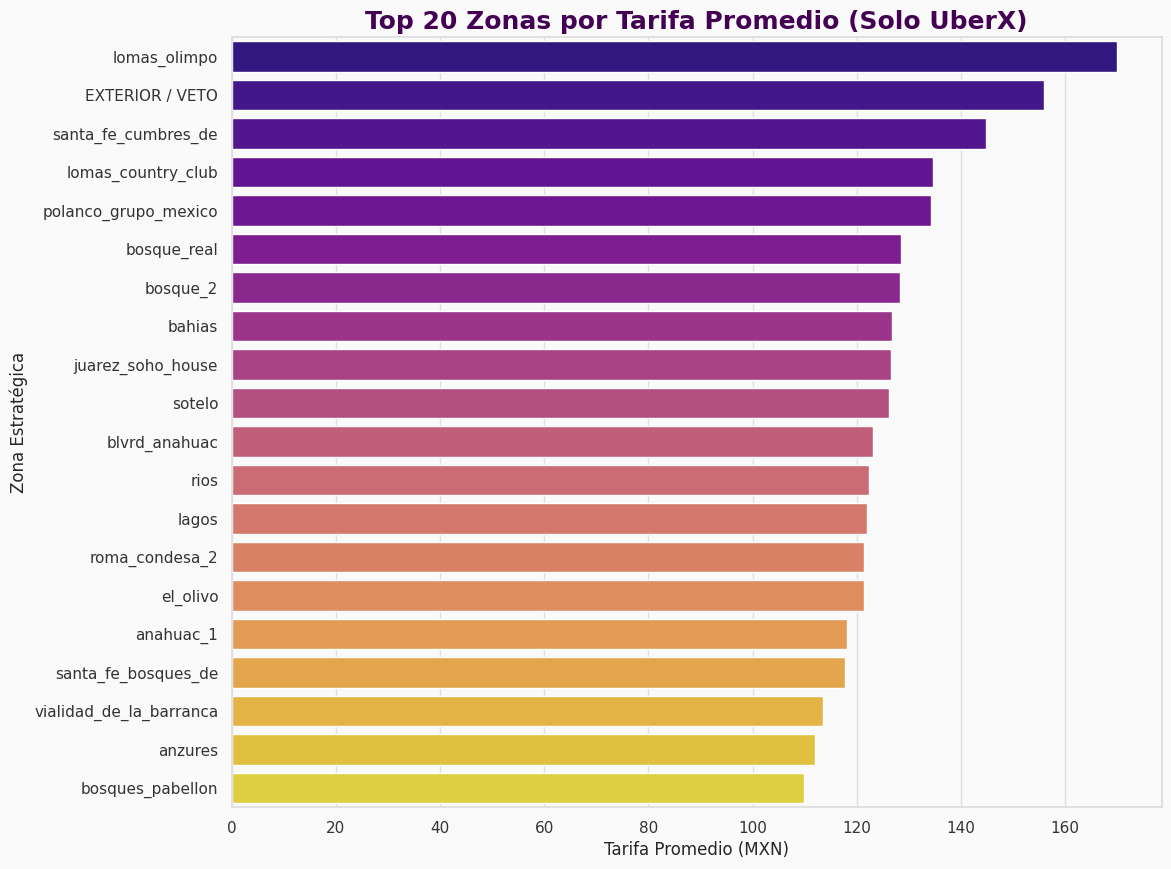

In [5]:
# ==============================================================================
# CELL: ANÁLISIS ECONÓMICO POR ZONA (UBERX-ONLY, CON GEOJSON)
# ==============================================================================
# Instalar dependencias geoespaciales si es necesario
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("### 💰 **Análisis Económico (UberX): Tarifa Promedio por Zona GeoJSON**"))

# --- 1. PREPARACIÓN ---
try:
    # Cargar los puntos (ofertas)
    query_points = "SELECT offer_id, dropoff_lat, dropoff_lon, upfront_fare, product_category_fk FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar los polígonos desde GeoJSON
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson' # <-- RUTA ACTUALIZADA
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    # Estandarizar nombre de columna (puede ser 'Name' o 'name')
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})
    gdf_zonas = gdf_zonas[['zone_name', 'geometry']]
    print(f"✅ {len(gdf_zonas)} polígonos cargados desde GeoJSON.")

    # Cargar el diccionario de categorías de producto
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()

    print("✅ Activos cargados (Puntos, Polígonos, Categorías).")

    # --- 2. ASIGNACIÓN DE ZONAS (POINT-IN-POLYGON) ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns='geometry'))
    print("✅ Zonas asignadas a cada oferta.")

    # --- 3. FILTRAR POR UBERX ---
    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk', # Columna en el df de la izquierda
        right_on='product_category_id', # Columna en el df de la derecha
        how='left'
    )
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print(f"✅ Filtrado por UberX. Total de ofertas: {len(df_uberx)}")

    # --- 4. CÁLCULO ---
    zone_economics_uberx = df_uberx.groupby('zone_name')['upfront_fare'].agg(['mean', 'count']).reset_index()
    zone_economics_uberx = zone_economics_uberx.rename(columns={'mean': 'avg_upfront_fare', 'count': 'offer_count'})
    zone_economics_uberx_sorted = zone_economics_uberx.sort_values('avg_upfront_fare', ascending=False)

    # --- 5. REPORTE Y VISUALIZACIÓN ---
    display(Markdown("#### **Ranking de Zonas por Tarifa Promedio (UberX)**"))
    display(zone_economics_uberx_sorted)

    top_n = 20
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_economics_uberx_sorted.head(top_n),
        y='zone_name',
        x='avg_upfront_fare',
        palette='plasma'
    )
    plt.title(f'Top {top_n} Zonas por Tarifa Promedio (Solo UberX)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('Tarifa Promedio (MXN)')
    plt.ylabel('Zona Estratégica')
    plt.show()

except FileNotFoundError:
    print(f"🔴 ERROR: Archivo GeoJSON no encontrado en: {GEOJSON_PATH}")
    print("   -> Por favor, verifique el nombre y la ubicación del archivo.")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### ⚡️ **Análisis de Eficiencia (UberX): `EPH Operacional` por Zona**

✅ Activos cargados.
✅ Fusión y filtrado completados. Total UberX: 3617


#### **Ranking de Zonas por Eficiencia Operacional (UberX)**

,zone_name,avg_eph_operational,offer_count
38,lomas_olimpo,309.090909,1
71,vistahermosa,251.312823,7
70,vialidad_de_la_barranca,234.136498,32
11,bosque_2,232.396571,5
9,bondojito_asf,230.180029,10
...,...,...,...
47,polanco_grupo_mexico,176.801583,11
7,bahias,172.971929,12
59,santa_fe_colegios,169.366927,19
39,lomas_prado_norte,160.463682,18


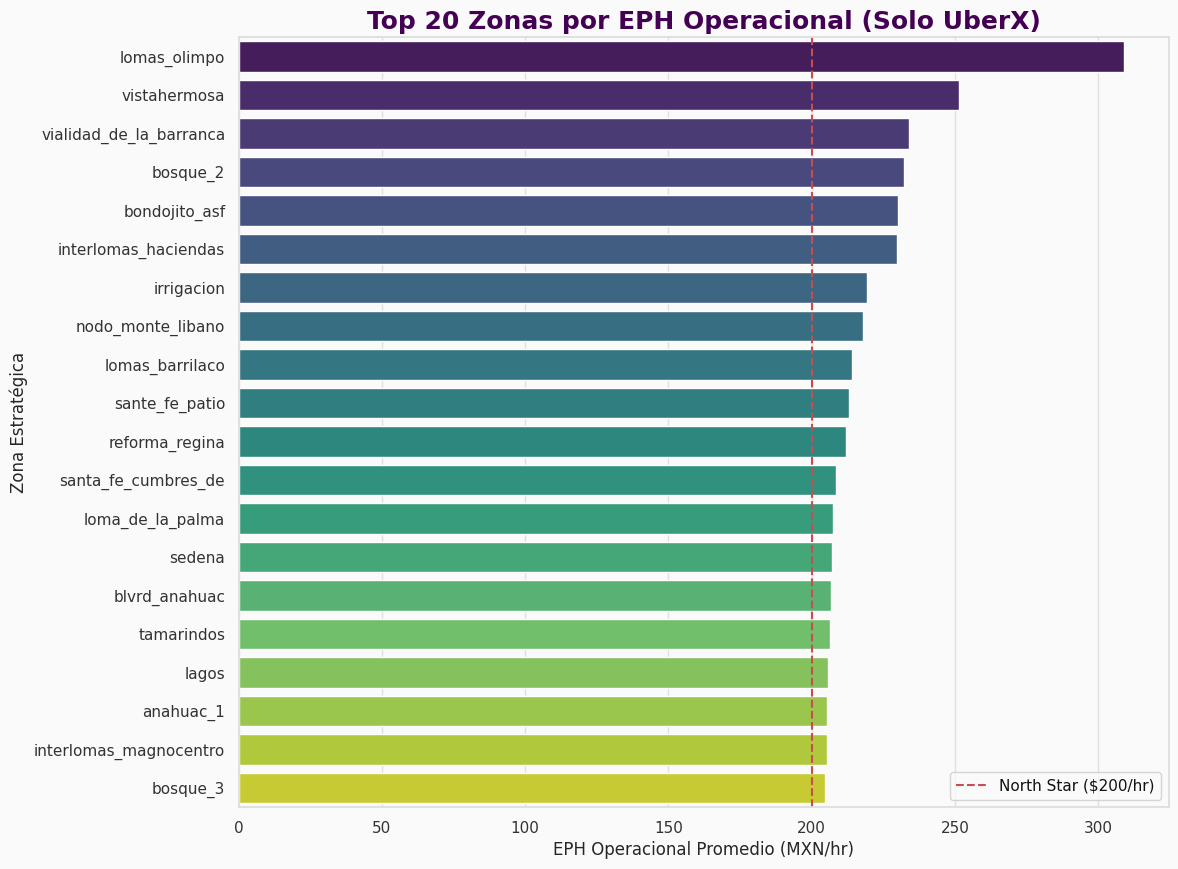

In [6]:
# ==============================================================================
# CELL: ANÁLISIS DE EFICIENCIA POR ZONA (EPH OP - UBERX - MONOLITO)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("### ⚡️ **Análisis de Eficiencia (UberX): `EPH Operacional` por Zona**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # 1. Cargar Puntos (AHORA incluyendo las features de ingeniería)
    query_points = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(df_points, geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat), crs="EPSG:4326")

    # 2. Cargar Polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})[['zone_name', 'geometry']]

    # 3. Cargar Categorías
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: FUSIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns='geometry'))

    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk',
        right_on='product_category_id',
        how='left'
    )

    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print(f"✅ Fusión y filtrado completados. Total UberX: {len(df_uberx)}")

    # --- FASE 3: ANÁLISIS ---
    # Higiene de Datos
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)

    # Cálculo
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].agg(['mean', 'count']).reset_index()
    zone_efficiency_uberx = zone_efficiency_uberx.rename(columns={'mean': 'avg_eph_operational', 'count': 'offer_count'})

    # SIN FILTROS, como pediste
    zone_efficiency_uberx_sorted = zone_efficiency_uberx.sort_values('avg_eph_operational', ascending=False)

    # --- FASE 4: REPORTE Y VISUALIZACIÓN ---
    display(Markdown("#### **Ranking de Zonas por Eficiencia Operacional (UberX)**"))
    display(zone_efficiency_uberx_sorted)

    top_n = 20
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_efficiency_uberx_sorted.head(top_n),
        y='zone_name',
        x='avg_eph_operational',
        palette='viridis'
    )
    plt.axvline(200, color='r', linestyle='--', label='North Star ($200/hr)')
    plt.title(f'Top {top_n} Zonas por EPH Operacional (Solo UberX)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('EPH Operacional Promedio (MXN/hr)')
    plt.ylabel('Zona Estratégica')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

In [7]:
# ==============================================================================
# CELL: MAPA DE CALOR DE RENTABILIDAD (EPH OPERACIONAL - UBERX)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🗺️ **Mapa de Calor de Rentabilidad (EPH Operacional - UberX)**"))

# --- FASE 1: RECONSTRUCCIÓN DE DATOS (AUTOCONTENIDO) ---
try:
    # Cargar todos los datos necesarios en una sola query
    query_full = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_master = pd.read_sql(query_full, db_engine)
    df_master.columns = df_master.columns.str.lower()

    gdf_points = gpd.GeoDataFrame(
        df_master,
        geometry=gpd.points_from_xy(df_master.dropoff_lon, df_master.dropoff_lat),
        crs="EPSG:4326"
    )

    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: ASIGNACIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas[['zone_name', 'geometry']], how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns=['geometry', 'index_right']))

    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk',
        right_on='product_category_id',
        how='left'
    )
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print("✅ Datos de UberX asignados a zonas.")

    # --- FASE 3: CÁLCULO DE MÉTRICA POR ZONA ---
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].mean().reset_index()

    # --- FASE 4: FUSIÓN FINAL PARA MAPA ---
    # Unimos la métrica calculada de vuelta al GeoDataFrame de polígonos
    gdf_map_data = pd.merge(gdf_zonas, zone_efficiency_uberx, on='zone_name', how='left')

    # Excluir la zona de VETO de la visualización
    gdf_map_data = gdf_map_data[gdf_map_data['zone_name'] != 'EXTERIOR / VETO']
    print("✅ Datos listos para el mapa.")

    # --- FASE 5: VISUALIZACIÓN CHOROPLETH ---
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_map_data,
        geojson=gdf_map_data.geometry,
        locations=gdf_map_data.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        opacity=0.7,
        height=900,
        title='Mapa de Calor de EPH Operacional (UberX)',
        color_continuous_scale="Viridis",
        labels={'eph_operational': 'EPH Operacional Promedio'}
    )
    fig.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🗺️ **Mapa de Calor de Rentabilidad (EPH Operacional - UberX)**

✅ Activos cargados.
✅ Datos de UberX asignados a zonas.
✅ Datos listos para el mapa.


In [8]:
# ==============================================================================
# CELL: MAPA DE CALOR DE RENTABILIDAD DIVERGENTE (EPH OP - UBERX - COMPLETA)
# ==============================================================================
# Instalar dependencias si es necesario
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🗺️ **Mapa de Calor Divergente: EPH Operacional (UberX) vs. Baseline**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # 1. Cargar Puntos (con todas las columnas necesarias)
    query_points = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )

    # 2. Cargar Polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})[['zone_name', 'geometry']]

    # 3. Cargar Categorías
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: ASIGNACIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns=['geometry', 'index_right']))

    df_analysis = pd.merge(df_zoned, df_categories, left_on='product_category_fk', right_on='product_category_id', how='left')
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print("✅ Datos de UberX asignados a zonas.")

    # --- FASE 3: CÁLCULO DE MÉTRICA ---
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].mean().reset_index()

    # --- FASE 4: FUSIÓN FINAL ---
    gdf_map_data = pd.merge(gdf_zonas, zone_efficiency_uberx, on='zone_name', how='left')
    gdf_map_data = gdf_map_data[gdf_map_data['zone_name'] != 'EXTERIOR / VETO']
    print("✅ Datos listos para el mapa.")

    # --- FASE 5: VISUALIZACIÓN DIVERGENTE ---
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_map_data,
        geojson=gdf_map_data.geometry,
        locations=gdf_map_data.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        opacity=0.75,
        height=900,
        title='Mapa de Calor de EPH Operacional (UberX) - Desviación de $200',
        hover_name='zone_name',

        # --- LA MAGIA ESTÁ AQUÍ ---
        color_continuous_scale="RdBu_r",
        range_color=[150, 250],

        labels={'eph_operational': 'EPH Operacional Promedio'}
    )

    fig.update_layout(coloraxis_colorbar=dict(
        title="EPH (MXN/hr)",
        tickvals=[150, 175, 200, 225, 250],
        ticktext=["$150 (Frío)", "$175", "$200 (Baseline)", "$225", "$250+ (Caliente)"]
    ))

    fig.show()

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 🗺️ **Mapa de Calor Divergente: EPH Operacional (UberX) vs. Baseline**

✅ Activos cargados.
✅ Datos de UberX asignados a zonas.
✅ Datos listos para el mapa.


In [9]:
# ==============================================================================
# CELL: VALIDACIÓN GEOESPACIAL DE RECHAZOS (PROXY & NON-OP)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🚦 **Validación Geoespacial de Rechazos: ¿Dónde viven los `Vetos`?**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
# Cargamos los datos necesarios: offer_id, coordenadas, y la razón de rechazo
query_validation = """
SELECT
    o.offer_id,
    o.dropoff_lat,
    o.dropoff_lon,
    rp.reason_primary_description AS reason_primary
FROM offers o
LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
WHERE
    o.dropoff_lat IS NOT NULL
    AND o.dropoff_lon IS NOT NULL
    AND rp.reason_primary_description IN ('dropoff_proxy', 'dropoff_non_operational')
"""
df_validation = pd.read_sql(query_validation, db_engine)
df_validation.columns = df_validation.columns.str.lower()
print(f"✅ Se cargaron {len(df_validation)} rechazos geo-relevantes.")

# --- FASE 2: VISUALIZACIÓN DE VALIDACIÓN ---
# Usamos Jitter para ver la densidad
np.random.seed(42)
noise_level = 0.0008
df_validation['lat_viz'] = df_validation['dropoff_lat'] + np.random.normal(0, noise_level, len(df_validation))
df_validation['lon_viz'] = df_validation['dropoff_lon'] + np.random.normal(0, noise_level, len(df_validation))

CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
fig = px.scatter_mapbox(
    df_validation,
    lat="lat_viz",
    lon="lon_viz",
    color="reason_primary", # Coloreamos por la razón del rechazo
    mapbox_style="carto-positron",
    center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
    zoom=10,
    height=900,
    title='Mapa de Distribución de Rechazos Geográficos',
    color_discrete_map={
        'dropoff_non_operational': 'firebrick',
        'dropoff_proxy': 'goldenrod'
    }
)

# --- FASE 3 (OPCIONAL): SUPERPONER LOS POLÍGONOS PARA LA PRUEBA FINAL ---
# Si quieres la prueba definitiva, descomenta estas líneas
# GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
# gdf_zonas = gpd.read_file(GEOJSON_PATH)
# fig.update_layout(
#     mapbox_layers=[
#         {
#             "sourcetype": "geojson",
#             "source": gdf_zonas.__geo_interface__,
#             "type": "line",
#             "color": "black",
#             "line": {"width": 1.5}
#         }
#     ]
# )

fig.show()

### 🚦 **Validación Geoespacial de Rechazos: ¿Dónde viven los `Vetos`?**

✅ Se cargaron 2602 rechazos geo-relevantes.


In [10]:
# ==============================================================================
# CELL: VALIDACIÓN GEOESPACIAL DE RECHAZOS (CON POLÍGONOS)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

display(Markdown("### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # Cargar los rechazos
    query_validation = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon,
        rp.reason_primary_description AS reason_primary
    FROM offers o
    LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
    WHERE
        o.dropoff_lat IS NOT NULL AND o.dropoff_lon IS NOT NULL
        AND rp.reason_primary_description IN ('dropoff_proxy', 'dropoff_non_operational')
    """
    df_validation = pd.read_sql(query_validation, db_engine)
    df_validation.columns = df_validation.columns.str.lower()
    print(f"✅ Se cargaron {len(df_validation)} rechazos geo-relevantes.")

    # Cargar los polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})
    print(f"✅ {len(gdf_zonas)} polígonos cargados.")

    # --- FASE 2: VISUALIZACIÓN HÍBRIDA ---
    df_validation['lat_viz'] = df_validation['dropoff_lat'] # No jitter, queremos precisión aquí
    df_validation['lon_viz'] = df_validation['dropoff_lon']

    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.scatter_mapbox(
        df_validation,
        lat="lat_viz",
        lon="lon_viz",
        color="reason_primary",
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        height=900,
        title='Validación: ¿Caen los Rechazos Donde Deberían?',
        color_discrete_map={
            'dropoff_non_operational': 'firebrick',
            'dropoff_proxy': 'goldenrod'
        }
    )

    # --- LA MAGIA: SUPERPONER LOS POLÍGONOS ---
    fig.update_layout(
        mapbox_layers=[
            {
                "sourcetype": "geojson",
                "source": gdf_zonas.__geo_interface__,
                "type": "line", # Solo dibujamos el borde
                "color": "black",
                "line": {"width": 1}
            }
        ]
    )

    fig.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**

✅ Se cargaron 2602 rechazos geo-relevantes.
✅ 72 polígonos cargados.


In [11]:
# ==============================================================================
# CELL: AUDITORÍA DE INCONSISTENCIAS GEO-SEMÁNTICAS
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd

display(Markdown("### 🚨 **Auditoría: Buscando Vetos en Zonas Seguras**"))

try:
    # --- 1. CARGAR DATOS ---
    # Cargar los rechazos "Non-Operational"
    query_vetos = "SELECT o.offer_id, o.dropoff_lat, o.dropoff_lon, rp.reason_primary_description FROM offers o JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id WHERE rp.reason_primary_description = 'dropoff_non_operational' AND o.dropoff_lat IS NOT NULL"
    df_vetos = pd.read_sql(query_vetos, db_engine)
    df_vetos.columns = df_vetos.columns.str.lower()
    gdf_vetos = gpd.GeoDataFrame(
        df_vetos,
        geometry=gpd.points_from_xy(df_vetos.dropoff_lon, df_vetos.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar tus polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    # Lista de zonas a excluir de la auditoría
    exclude_zones = ['Proxy', 'Herradura / Conscripto']
    gdf_zonas_seguras = gdf_zonas[~gdf_zonas['zone_name'].isin(exclude_zones)]
    print(f"✅ {len(gdf_vetos)} Vetos y {len(gdf_zonas_seguras)} Zonas Seguras cargados.")

    # --- 2. LA INTERSECCIÓN (LA BÚSQUEDA) ---
    print("\n⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...")
    # Realizar el sjoin
    gdf_inconsistencias = gpd.sjoin(gdf_vetos, gdf_zonas_seguras, how="inner", predicate='within')

    # --- 3. EL REPORTE DE HALLAZGOS ---
    num_inconsistencias = len(gdf_inconsistencias)

    if num_inconsistencias > 0:
        display(Markdown(f"### 🔴 **¡ALERTA! Se encontraron {num_inconsistencias} inconsistencias:**"))

        # Agrupar por zona para ver dónde están los problemas
        reporte = gdf_inconsistencias.groupby('zone_name').agg(
            conteo_inconsistencias=('offer_id', 'count'),
            ids_de_oferta=('offer_id', lambda x: ', '.join(x))
        ).reset_index()

        display(reporte)

        display(Markdown("""
        **Análisis:**
        Estos son `offer_id`s que fueron etiquetados como `dropoff_non_operational` pero cuyas coordenadas cayeron DENTRO de un polígono que definiste como seguro.
        **Causas Posibles:**
        1.  **Error de Etiquetado Manual:** Etiquetaste mal la razón de rechazo.
        2.  **Error de Geocodificación:** Las coordenadas están mal y no pertenecen a esa zona.
        3.  **Error en el Polígono:** El polígono que dibujaste es demasiado grande y abarca un área que a veces consideras "non-operational".
        """))
    else:
        display(Markdown("### ✅ **¡VoBo! Cero Inconsistencias Encontradas.**"))
        display(Markdown("Tu etiquetado y tus polígonos son consistentes. Los rechazos geográficos están correctamente fuera de las zonas seguras."))

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚨 **Auditoría: Buscando Vetos en Zonas Seguras**

✅ 2363 Vetos y 72 Zonas Seguras cargados.

⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...


### 🔴 **¡ALERTA! Se encontraron 279 inconsistencias:**

,zone_name,conteo_inconsistencias,ids_de_oferta
0,agwa_bezares,1,OF01010
1,ahuehuetes_sur,2,"OF01774, OF04336"
2,anahuac_1,1,OF01451
3,anzures,1,OF00304
4,ave_club_de_golf_lomas,1,OF00331
5,bahias,1,OF01557
6,blvrd_anahuac,1,OF02933
7,bondojito_asf,7,"OF00146, OF00656, OF01225, OF02818, OF03728, O..."
8,bosque_2,1,OF01941
9,bosque_3,2,"OF02400, OF04088"



        **Análisis:**
        Estos son `offer_id`s que fueron etiquetados como `dropoff_non_operational` pero cuyas coordenadas cayeron DENTRO de un polígono que definiste como seguro.
        **Causas Posibles:**
        1.  **Error de Etiquetado Manual:** Etiquetaste mal la razón de rechazo.
        2.  **Error de Geocodificación:** Las coordenadas están mal y no pertenecen a esa zona.
        3.  **Error en el Polígono:** El polígono que dibujaste es demasiado grande y abarca un área que a veces consideras "non-operational".
        

In [12]:
# ==============================================================================
# CELL: AUDITORÍA DE INCONSISTENCIAS GEO-SEMÁNTICAS (VERSIÓN DETALLADA)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd

display(Markdown("### 🚨 **Auditoría Detallada: Buscando Vetos en Zonas Seguras**"))

try:
    # --- 1. CARGAR DATOS ---
    # Cargar los rechazos "Non-Operational" CON la dirección de texto
    query_vetos = """
    SELECT
        o.offer_id,
        o.dropoff_address, -- <--- AÑADIDO
        o.dropoff_lat,
        o.dropoff_lon
    FROM offers o
    JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
    WHERE rp.reason_primary_description = 'dropoff_non_operational'
    AND o.dropoff_lat IS NOT NULL
    """
    df_vetos = pd.read_sql(query_vetos, db_engine)
    df_vetos.columns = df_vetos.columns.str.lower()
    gdf_vetos = gpd.GeoDataFrame(
        df_vetos,
        geometry=gpd.points_from_xy(df_vetos.dropoff_lon, df_vetos.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar tus polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    exclude_zones = ['Proxy', 'Herradura / Conscripto']
    gdf_zonas_seguras = gdf_zonas[~gdf_zonas['zone_name'].isin(exclude_zones)]
    print(f"✅ Activos cargados: {len(gdf_vetos)} Vetos y {len(gdf_zonas_seguras)} Zonas Seguras.")

    # --- 2. LA INTERSECCIÓN ---
    print("\n⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...")
    gdf_inconsistencias = gpd.sjoin(gdf_vetos, gdf_zonas_seguras, how="inner", predicate='within')

    # --- 3. EL REPORTE DE HALLAZGOS (LISTA COMPLETA) ---
    num_inconsistencias = len(gdf_inconsistencias)

    if num_inconsistencias > 0:
        display(Markdown(f"### 🔴 **¡ALERTA! Se encontraron {num_inconsistencias} inconsistencias:**"))

        # Seleccionar y reordenar columnas para el informe final
        reporte_detallado = gdf_inconsistencias[[
            'offer_id',
            'zone_name', # La zona "segura" en la que cayó
            'dropoff_address',
            'dropoff_lat',
            'dropoff_lon'
        ]].sort_values('zone_name')

        # --- NO AGREGAR, MOSTRAR TODO ---
        pd.set_option('display.max_rows', num_inconsistencias + 1) # Asegurarse de que Pandas no trunque la lista
        display(reporte_detallado)
        pd.reset_option('display.max_rows')

    else:
        display(Markdown("### ✅ **¡VoBo! Cero Inconsistencias Encontradas.**"))

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚨 **Auditoría Detallada: Buscando Vetos en Zonas Seguras**

✅ Activos cargados: 2363 Vetos y 72 Zonas Seguras.

⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...


### 🔴 **¡ALERTA! Se encontraron 279 inconsistencias:**

,offer_id,zone_name,dropoff_address,dropoff_lat,dropoff_lon
479,OF01010,agwa_bezares,"Fresnos 87, Granjas Palo Alto, Cuajimalpa de M...",19.382381,-99.257111
2159,OF04336,ahuehuetes_sur,"Calle De Bosque de Duraznos Piso 11 67, Col Bo...",19.404960,-99.241322
856,OF01774,ahuehuetes_sur,"Calle Bosque de Cerezos 12, Bosques de Las Lom...",19.395247,-99.250953
701,OF01451,anahuac_1,"Lago Xochimilco 343, Anáhuac I Secc, Miguel Hi...",19.437923,-99.179729
139,OF00304,anzures,"11100 Miguel Hidalgo, CMX - Polanco / Anzures",19.432658,-99.177446
156,OF00331,ave_club_de_golf_lomas,"B. de Las Palmas, Bosque de las Palmas, 52787 ...",19.401497,-99.277617
749,OF01557,bahias,"Calz México Tacuba 94, Col Tlaxpana, 11370 Mig...",19.437603,-99.172515
1513,OF02933,blvrd_anahuac,"Calle Fuente Portal de Las Flores 40, 52788 Mi...",19.393937,-99.271345
1876,OF03728,bondojito_asf,"Sur 136 116, Col Las Américas Álvaro Obregón, ...",19.400941,-99.204089
293,OF00656,bondojito_asf,"Col Las Américas Álvaro Obregón, 01120 Ciudad ...",19.399550,-99.205306


In [13]:
# ==============================================================================
# CELL: DIAGNÓSTICO DE GEOMETRÍA DE POLÍGONOS
# ==============================================================================
import geopandas as gpd
from IPython.display import display, Markdown

# --- 1. CARGA ---
GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})
print(f"✅ {len(gdf_zonas)} polígonos cargados desde GeoJSON.")

# --- 2. EL DIAGNÓSTICO ---
display(Markdown("### 🩺 **Reporte de Salud Geométrica**"))

# Creamos una columna para verificar la validez de cada polígono
gdf_zonas['is_valid'] = gdf_zonas.geometry.is_valid

# Buscamos al culpable
culpable = gdf_zonas[gdf_zonas['zone_name'] == 'carretera_al_olivo']

if not culpable.empty:
    es_valido = culpable['is_valid'].iloc[0]
    display(Markdown(f"- **Estado de 'carretera_al_olivo':** {'✅ Válido' if es_valido else '🔴 INVÁLIDO'}"))

# Mostramos TODOS los polígonos inválidos
invalid_polygons = gdf_zonas[~gdf_zonas['is_valid']]

if not invalid_polygons.empty:
    display(Markdown("\n### 🚨 **Polígonos con Geometría Inválida Detectados:**"))
    display(invalid_polygons[['zone_name', 'is_valid']])

    # --- 3. INTENTO DE REPARACIÓN AUTOMÁTICA ---
    display(Markdown("\n### 🛠️ **Intentando Reparación Automática...**"))
    # 'buffer(0)' es un truco común en geopandas para arreglar geometrías inválidas
    gdf_zonas['geometry'] = gdf_zonas.geometry.buffer(0)
    gdf_zonas['is_valid_after_fix'] = gdf_zonas.geometry.is_valid

    fixed_count = gdf_zonas['is_valid_after_fix'].sum() - gdf_zonas['is_valid'].sum()

    if fixed_count > 0:
        display(Markdown(f"✅ **¡Éxito!** Se repararon **{fixed_count}** polígonos."))
        display(gdf_zonas[['zone_name', 'is_valid', 'is_valid_after_fix']])
    else:
        display(Markdown("⚠️ No se pudo reparar automáticamente. El problema puede ser más complejo."))
else:
    display(Markdown("\n✅ **Todos los polígonos tienen geometrías válidas.**"))

✅ 72 polígonos cargados desde GeoJSON.


### 🩺 **Reporte de Salud Geométrica**

- **Estado de 'carretera_al_olivo':** ✅ Válido


✅ **Todos los polígonos tienen geometrías válidas.**

In [14]:
# ==============================================================================
# CELL: AISLAMIENTO Y VERIFICACIÓN DE POLÍGONO FANTASMA
# ==============================================================================

# 1. AISLAR AL SOSPECHOSO
poligono_fantasma = gdf_zonas[gdf_zonas['zone_name'] == 'carretera_al_olivo']

# 2. INTERROGATORIO DE PROPIEDADES
if not poligono_fantasma.empty:
    display(Markdown("### 🕵️ **Interrogatorio de 'carretera_al_olivo'**"))

    # Propiedad 1: ¿Qué tipo de geometría eres?
    geom_type = poligono_fantasma.iloc[0].geometry.geom_type
    display(Markdown(f"- **Tipo de Geometría:** `{geom_type}`"))

    # Propiedad 2: ¿Cuál es tu área? (en grados cuadrados, solo para ver si no es cero)
    area = poligono_fantasma.iloc[0].geometry.area
    display(Markdown(f"- **Área Calculada:** `{area}`"))

    if area == 0:
        display(Markdown("   - 🔴 **¡ALERTA!** El área es cero. El polígono es una línea o un punto."))

    # 3. INTENTO DE VISUALIZACIÓN EN AISLAMIENTO
    display(Markdown("\n### 🗺️ **Visualización Forzada**"))
    # Centramos el mapa en el propio centroide del polígono
    center_lon, center_lat = poligono_fantasma.iloc[0].geometry.centroid.coords[0]

    fig = px.choropleth_mapbox(
        poligono_fantasma,
        geojson=poligono_fantasma.geometry,
        locations=poligono_fantasma.index,
        color_discrete_sequence=['red'], # Un solo color para que resalte
        mapbox_style="carto-positron",
        center={"lat": center_lat, "lon": center_lon},
        zoom=15, # Zoom masivo
        opacity=0.8,
        height=700
    )
    fig.show()

else:
    display(Markdown("🔴 **ERROR:** El polígono 'carretera_al_olivo' no fue encontrado en el GeoJSON."))

### 🕵️ **Interrogatorio de 'carretera_al_olivo'**

- **Tipo de Geometría:** `Polygon`

- **Área Calculada:** `5.872276246001079e-05`


### 🗺️ **Visualización Forzada**

In [15]:
# ==============================================================================
# CELL: MAPA HÍBRIDO DEFINITIVO (POLÍGONOS CON DATOS + VACÍOS)
# ==============================================================================
# ... (Todo el código de Carga, Fusión y Cálculo hasta 'gdf_map_data' es el mismo de la celda del mapa de calor) ...

# --- FASE 5: VISUALIZACIÓN HÍBRIDA ---
if 'gdf_map_data' in locals():

    # 1. Separar los polígonos con datos de los vacíos
    gdf_con_datos = gdf_map_data.dropna(subset=['eph_operational'])
    gdf_vacios = gdf_map_data[gdf_map_data['eph_operational'].isna()]

    print(f"✅ Se visualizarán {len(gdf_con_datos)} polígonos con datos.")
    if not gdf_vacios.empty:
        print(f"⚠️ Se dibujarán los bordes de {len(gdf_vacios)} polígonos vacíos, incluyendo: {gdf_vacios['zone_name'].tolist()}")

    # 2. Crear la figura base con los polígonos de datos (choropleth)
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_con_datos,
        geojson=gdf_con_datos.geometry,
        locations=gdf_con_datos.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5, opacity=0.7, height=900,
        title='Mapa Híbrido: Calor de Zonas con Datos + Bordes de Zonas Vacías',
        color_continuous_scale="Viridis",
        labels={'eph_operational': 'EPH Operacional Promedio'}
    )

    # 3. Añadir la capa de bordes para los polígonos vacíos
    if not gdf_vacios.empty:
        fig.update_layout(
            mapbox_layers=[
                {
                    "sourcetype": "geojson",
                    "source": gdf_vacios.__geo_interface__,
                    "type": "line",
                    "color": "grey", # Color del borde para los vacíos
                    "line": {"width": 1.5}
                }
            ]
        )

    fig.show()
else:
    print("🔴 ERROR: Ejecute la celda de cálculo de métricas por zona primero.")

✅ Se visualizarán 72 polígonos con datos.


In [33]:
# ==============================================================================
# CELL: RENOMBRADO FINAL (Standardization)
# ==============================================================================

# 1. DEFINIR CAMBIO
# Buscamos todo lo que tenga ID -1 (lo que quedó fuera de polígonos)
mask_unassigned = df_audit_final['polygon_id'] == -1
count_unassigned = mask_unassigned.sum()

# 2. APLICAR CAMBIO
if count_unassigned > 0:
    df_audit_final.loc[mask_unassigned, 'polygon_name'] = 'unassigned'
    print(f"✅ Se renombraron {count_unassigned} registros de 'EXTERIOR / VETO' a 'unassigned'.")
else:
    print("ℹ️ No se encontraron registros con ID -1 para renombrar.")

# 3. RE-EXPORTAR (Para guardar este último cambio)
OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv'
df_audit_final.to_csv(OUTPUT_PATH, index=False)

print(f"💾 Archivo final actualizado en: {OUTPUT_PATH}")

✅ Se renombraron 2187 registros de 'EXTERIOR / VETO' a 'unassigned'.
💾 Archivo final actualizado en: /content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv


In [32]:
# ==============================================================================
# CELL: INSPECCIÓN FORENSE VISUAL (Con Direcciones)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd

# 1. Recuperar datos (Memoria o CSV)
try:
    df_investigation = df_audit_final.copy() # Usamos la versión en memoria si existe
    print("✅ Analizando dataframe en memoria (df_audit_final).")
except NameError:
    # Fallback si se reinició el entorno
    OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv'
    df_investigation = pd.read_csv(OUTPUT_PATH)
    print(f"⚠️ Variable no encontrada. Leyendo desde disco: {OUTPUT_PATH}")

# 2. Filtrar duplicados
# keep=False para mostrar TODOS los involucrados en el conflicto
dupes_mask = df_investigation.duplicated(subset=['offer_id'], keep=False)
df_dupes = df_investigation[dupes_mask].sort_values(by=['offer_id', 'polygon_name'])

# 3. Visualización Táctica
num_dupes_ids = df_dupes['offer_id'].nunique()

if num_dupes_ids == 0:
    display(Markdown("### ✅ Todo limpio. No hay duplicados."))
else:
    display(Markdown(f"### 🚨 CONFLICTO DETECTADO: {num_dupes_ids} IDs duplicados"))
    display(Markdown("Compara **`dropoff_address`** vs **`polygon_name`** para decidir cuál es el correcto."))

    # Columnas clave para tu decisión
    cols_to_view = [
        'offer_id',
        'dropoff_address',  # <--- Agregado para contexto
        'polygon_name',     # <--- El culpable del conflicto
        'polygon_id',
        'dropoff_lat',
        'dropoff_lon'
    ]

    # Mostramos la tabla
    display(df_dupes[cols_to_view])

✅ Analizando dataframe en memoria (df_audit_final).


### ✅ Todo limpio. No hay duplicados.

In [31]:
# ==============================================================================
# CELL: EJECUCIÓN DE SENTENCIA (Corrección Manual Definitiva)
# ==============================================================================

# 1. TUS DECISIONES (Ya precargadas)
manual_fixes = {
    'OF01459': 'lomas_fc_cuernavaca',  # Periférico lado Lomas
    'OF03579': 'lomas_fc_cuernavaca',  # Periférico lado Lomas (segundo caso)
    'OF03984': 'roma_condesa_1'        # Jojutla 6 es Condesa
}

print(f"🔧 Iniciando corrección manual para {len(manual_fixes)} conflictos...")

# 2. APLICAR CORRECCIONES
# Estrategia: Para los IDs conflictivos, SOLO mantenemos la fila que coincide con tu elección.
ids_to_fix = list(manual_fixes.keys())

# Creamos una máscara inicial: "Todas las filas son válidas"
keep_mask = pd.Series([True] * len(df_audit_final), index=df_audit_final.index)

for oid, target_poly in manual_fixes.items():
    # Identificamos las filas de este ID específico
    id_rows = df_audit_final['offer_id'] == oid

    # Dentro de esas filas, identificamos cuál es la "mala" (la que NO es el target)
    # y marcamos False en la máscara de "mantener".
    bad_rows = id_rows & (df_audit_final['polygon_name'] != target_poly)

    if bad_rows.any():
        keep_mask[bad_rows] = False
        print(f"  ✅ ID {oid}: Se eliminó el polígono incorrecto, nos quedamos con '{target_poly}'.")
    else:
        print(f"  ⚠️ ID {oid}: No encontré conflictos que eliminar. ¿Ya estaba limpio?")

# Aplicamos el filtro
df_audit_final = df_audit_final[keep_mask]

# 3. SEGURIDAD FINAL (Deduplicación técnica)
# Por si acaso hubiera ALGÚN otro duplicado no detectado, eliminamos arbitrariamente
# para garantizar unicidad (Primary Key: offer_id).
dupes_remaining = df_audit_final.duplicated(subset=['offer_id']).sum()
if dupes_remaining > 0:
    print(f"🧹 Eliminando {dupes_remaining} duplicados residuales automáticos...")
    df_audit_final = df_audit_final.drop_duplicates(subset=['offer_id'], keep='first')

# 4. GUARDADO FINAL
OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv'
df_audit_final.to_csv(OUTPUT_PATH, index=False)

print("-" * 30)
print(f"💾 EXPORTACIÓN COMPLETADA.")
print(f"📊 Total de filas únicas: {len(df_audit_final)}")
print(f"📂 Archivo actualizado: {OUTPUT_PATH}")

🔧 Iniciando corrección manual para 3 conflictos...
  ⚠️ ID OF01459: No encontré conflictos que eliminar. ¿Ya estaba limpio?
  ⚠️ ID OF03579: No encontré conflictos que eliminar. ¿Ya estaba limpio?
  ⚠️ ID OF03984: No encontré conflictos que eliminar. ¿Ya estaba limpio?
------------------------------
💾 EXPORTACIÓN COMPLETADA.
📊 Total de filas únicas: 4765
📂 Archivo actualizado: /content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv


In [16]:
'''# ==============================================================================
# CELL: EXPORTACIÓN PARA AUDITORÍA MASIVA DE POLÍGONOS
# ==============================================================================
from IPython.display import display, Markdown

# ASUNCIÓN: `gdf_merged` (el resultado del sjoin) existe en memoria.
# Para seguridad, lo reconstruiremos desde cero.

display(Markdown("### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**"))

try:
    # --- 1. RECONSTRUCCIÓN COMPLETA DE DATOS ---
    # Cargar todos los puntos con sus datos de texto
    query_full = "SELECT offer_id, pickup_address, dropoff_address, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon FROM offers"
    df_export_raw = pd.read_sql(query_full, db_engine)
    gdf_points_export = gpd.GeoDataFrame(
        df_export_raw,
        geometry=gpd.points_from_xy(df_export_raw.dropoff_lon, df_export_raw.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar los polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'polygon_name'})
    gdf_zonas['polygon_id'] = gdf_zonas.index # Creamos un ID numérico simple

    print("✅ Activos cargados (Puntos y Polígonos).")

    # --- 2. FUSIÓN GEOESPACIAL ---
    gdf_export_merged = gpd.sjoin(gdf_points_export, gdf_zonas[['polygon_name', 'polygon_id', 'geometry']], how="left", predicate='within')
    gdf_export_merged.drop(columns=['geometry', 'index_right'], inplace=True)
    gdf_export_merged['polygon_name'] = gdf_export_merged['polygon_name'].fillna('EXTERIOR / VETO')
    gdf_export_merged['polygon_id'] = gdf_export_merged['polygon_id'].fillna(-1) # Asignamos -1 al Ruido
    print("✅ Fusión completada.")

    # --- 3. SELECCIÓN Y ORDENAMIENTO FINAL ---
    # Seleccionar y reordenar las columnas al formato exacto que pediste
    final_columns = [
        'offer_id',
        'pickup_address',
        'dropoff_address',
        'pickup_lat',
        'pickup_lon',
        'dropoff_lat',
        'dropoff_lon',
        'polygon_id',
        'polygon_name'
    ]
    df_audit_final = gdf_export_merged[final_columns].sort_values(['polygon_id', 'offer_id'])

    # --- 4. EXPORTACIÓN A GOOGLE DRIVE ---
    OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv'
    df_audit_final.to_csv(OUTPUT_PATH, index=False)

    display(Markdown(f"✅ **¡Auditoría Exportada!** El archivo está listo en:"))
    display(Markdown(f"`{OUTPUT_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR: {e}")'''

### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**

✅ Activos cargados (Puntos y Polígonos).
✅ Fusión completada.


✅ **¡Auditoría Exportada!** El archivo está listo en:

`/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv`

In [17]:
# ==============================================================================
# CELL: LA FORJA DEL DICCIONARIO H3 (LA VERSIÓN CORRECTA)
# ==============================================================================
# Instalar la versión correcta y verificada
!pip install h3 --upgrade

import h3
import geopandas as gpd
from IPython.display import display, Markdown
import json

display(Markdown("### ⬢ **Operación Teselado: Polígonos -> Hexágonos**"))

# --- 1. CONFIGURACIÓN ---
H3_RESOLUTION = 9 # Nivel de "cuadra"
GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson' # <-- ¡VERIFICA!

# --- 2. CARGA DE POLÍGONOS ---
try:
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    # Estandarizar nombre de columna
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})

    print(f"✅ {len(gdf_zonas)} polígonos cargados para teselado.")

    # --- 3. EL "POLYFILL" CON LA FUNCIÓN CORRECTA ---
    print(f"⏳ Realizando 'polyfill' con resolución H3={H3_RESOLUTION}...")

    hex_to_zone_map = {}

    for index, row in gdf_zonas.iterrows():
        # Extraer la geometría en el formato __geo_interface__ que la librería espera
        geojson_polygon = row.geometry.__geo_interface__

        # --- LA LLAVE MAESTRA ---
        # Usamos la función directa y recomendada por la documentación
        hexagons = h3.geo_to_cells(geojson_polygon, H3_RESOLUTION)
        # ----------------------

        for hex_id in hexagons:
            hex_to_zone_map[hex_id] = row['zone_name']

    print("✅ ¡Polyfill completado!")

    # --- 4. REPORTE Y GUARDADO ---
    num_hexagons = len(hex_to_zone_map)
    display(Markdown(f"### 🗺️ **Diccionario Maestro H3 Creado**\n*   **Total de Hexágonos Únicos:** `{num_hexagons}`\n*   **Resolución:** `{H3_RESOLUTION}`"))

    dict_output_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_zone_dictionary.json'
    with open(dict_output_path, 'w') as f:
        json.dump(hex_to_zone_map, f)

    display(Markdown(f"✅ **Diccionario guardado en:** `{dict_output_path}`"))

except FileNotFoundError:
    print(f"🔴 ERROR: Archivo GeoJSON no encontrado en: {GEOJSON_PATH}")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### ⬢ **Operación Teselado: Polígonos -> Hexágonos**

✅ 72 polígonos cargados para teselado.
⏳ Realizando 'polyfill' con resolución H3=9...
✅ ¡Polyfill completado!


### 🗺️ **Diccionario Maestro H3 Creado**
*   **Total de Hexágonos Únicos:** `685`
*   **Resolución:** `9`

✅ **Diccionario guardado en:** `/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_zone_dictionary.json`

In [22]:
# ==============================================================================
# CELL: CRISTALIZACIÓN ESTRUCTURAL (JSON -> TABLA MAESTRA)
# ==============================================================================
import pandas as pd

display(Markdown("### 💎 **Operación Cristal: Creando Tabla Maestra de Hexágonos**"))

# --- 1. CONVERSIÓN DICT -> DATAFRAME ---
# Convertimos el diccionario que vive en memoria (hex_to_zone_map) en una tabla real
print("⏳ Transmutando diccionario a estructura tabular...")

df_h3_master = pd.DataFrame(list(hex_to_zone_map.items()), columns=['h3_index', 'zone_name'])

# Añadimos la resolución como metadato, útil para no mezclar peras con manzanas en el futuro
df_h3_master['resolution'] = H3_RESOLUTION

# --- 2. VALIDACIÓN DE INTEGRIDAD ---
total_rows = df_h3_master.shape[0]
unique_hexes = df_h3_master['h3_index'].nunique()

if total_rows == unique_hexes:
    print(f"✅ INTEGRIDAD PERFECTA: {total_rows} Hexágonos únicos confirmados.")
else:
    print(f"⚠️ ALERTA: Se encontraron duplicados ({total_rows} filas vs {unique_hexes} únicos).")

# --- 3. EXPORTACIÓN ---
csv_output_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/master_h3_zones.csv'
df_h3_master.to_csv(csv_output_path, index=False)

display(Markdown(f"### 💾 **Artefacto Tabular Guardado:** `{csv_output_path}`"))
display(Markdown("*Este archivo está listo para ser ingestada como la tabla `dim_h3_zones` en Opus.db*"))

# --- 4. VISTA PREVIA ---
print("\nMuestra de la Matriz Hexagonal:")
display(df_h3_master.head())

### 💎 **Operación Cristal: Creando Tabla Maestra de Hexágonos**

⏳ Transmutando diccionario a estructura tabular...
✅ INTEGRIDAD PERFECTA: 685 Hexágonos únicos confirmados.


### 💾 **Artefacto Tabular Guardado:** `/content/drive/MyDrive/_Pienza/Assets/Phase_2/master_h3_zones.csv`

*Este archivo está listo para ser ingestada como la tabla `dim_h3_zones` en Opus.db*


Muestra de la Matriz Hexagonal:


,h3_index,zone_name,resolution
0,894995bac43ffff,polanco_parque_lincoln,9
1,894995bae93ffff,polanco_parque_lincoln,9
2,894995bac5bffff,polanco_parque_lincoln,9
3,894995bae83ffff,polanco_parque_lincoln,9
4,894995bae97ffff,polanco_parque_lincoln,9


In [27]:
# ==============================================================================
# CELL: THE FUSION LINK (FULL UNIVERSE VERSION - N=4765)
# ==============================================================================
# Objective: Generate H3 Links for EVERY offer, preserving row count integrity.
# ==============================================================================

# --- 0. CONSTANTS ---
H3_RESOLUTION = 9
import h3

display(Markdown("### 🔗 **Operación Fusión: Universo Completo**"))

# --- 1. EXTRACTION (NO FILTERS) ---
print(f"📡 Querying Opus.db ({DB_PATH})...")

# CAMBIO CRÍTICO: Quitamos el "WHERE ... IS NOT NULL"
# Queremos todas las filas, incluso las 'Ghost Offers' si existen.
query = """
SELECT
    offer_id,
    dropoff_lat,
    dropoff_lon
FROM offers
"""

df_offers_geo = pd.read_sql(query, db_engine)
current_count = len(df_offers_geo)
print(f"✅ Cargados {current_count} registros totales (Universo Completo).")

# --- 2. H3 CALCULATION (ROBUST) ---
print(f"⬢ Calculando índices H3 (Res: {H3_RESOLUTION})...")

def get_hex_safe(lat, lon, res):
    # Si lat/lon son None o NaN, regresamos None inmediatamente
    if pd.isna(lat) or pd.isna(lon):
        return None
    try:
        return h3.latlng_to_cell(lat, lon, res)
    except (ValueError, TypeError):
        return None

df_offers_geo['dropoff_h3_hex_id'] = df_offers_geo.apply(
    lambda x: get_hex_safe(x['dropoff_lat'], x['dropoff_lon'], H3_RESOLUTION), axis=1
)

# --- 3. THE MERGE (SEMANTICS) ---
print("🔗 Cruzando con Semántica de Polígonos...")

# Load Master if missing
if 'df_h3_master' not in locals():
    try:
        df_h3_master = pd.read_csv('/content/drive/MyDrive/_Pienza/Assets/Phase_2/master_h3_zones.csv')
    except:
        raise ValueError("CRITICAL: Ejecuta la celda anterior para generar master_h3_zones.csv")

# LEFT JOIN es la clave para mantener las 4765 filas
df_fused = df_offers_geo.merge(
    df_h3_master[['h3_index', 'zone_name']],
    left_on='dropoff_h3_hex_id',
    right_on='h3_index',
    how='left'
)

# Renaming for Schema Alignment (Addendum 205)
# zone_name from polygon -> dropoff_polygon_name
df_fused = df_fused.rename(columns={'zone_name': 'dropoff_polygon_name'})

# --- 4. AUDIT & CLEANUP ---
# Seleccionamos columnas finales para el CSV
final_cols = ['offer_id', 'dropoff_h3_hex_id', 'dropoff_polygon_name']
df_final_link = df_fused[final_cols]

# Auditoría de Integridad
final_count = len(df_final_link)
assert final_count == current_count, f"❌ ERROR DE DILUCIÓN: {current_count} vs {final_count}"

print("-" * 40)
print(f"Total Offers (Input):  {current_count}")
print(f"Total Rows (Output):   {final_count}")
print(f"Offers inside Zones:   {df_final_link['dropoff_polygon_name'].notnull().sum()}")
print(f"Offers outside Zones:  {df_final_link['dropoff_polygon_name'].isnull().sum()}")
print("-" * 40)

display(df_final_link.head())

# --- 5. EXPORT ---
output_link_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_hex_id.csv'
df_final_link.to_csv(output_link_path, index=False)
display(Markdown(f"✅ **Artefacto 'Silver Layer' Generado:** `{output_link_path}`"))

### 🔗 **Operación Fusión: Universo Completo**

📡 Querying Opus.db (/content/drive/MyDrive/_Pienza/Assets/Phase_2/opus.db)...
✅ Cargados 4765 registros totales (Universo Completo).
⬢ Calculando índices H3 (Res: 9)...
🔗 Cruzando con Semántica de Polígonos...
----------------------------------------
Total Offers (Input):  4765
Total Rows (Output):   4765
Offers inside Zones:   2544
Offers outside Zones:  2221
----------------------------------------


,offer_id,dropoff_h3_hex_id,dropoff_polygon_name
0,OF00001,89499516bafffff,NaN
1,OF00002,894995b1dd7ffff,NaN
2,OF00003,None,NaN
3,OF00004,894995bac03ffff,lomas_prado_norte
4,OF00005,894995bab23ffff,NaN


✅ **Artefacto 'Silver Layer' Generado:** `/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_hex_id.csv`

In [18]:
# ==============================================================================
# CELL: LA LLAVE MAESTRA DE COLAB (Habilitar Widgets)
# ==============================================================================
from google.colab import output

# Esto le dice a Colab: "Confía en los widgets externos (como Kepler)"
output.enable_custom_widget_manager()

print("✅ Widgets de terceros habilitados. Ahora el mapa debería verse.")

✅ Widgets de terceros habilitados. Ahora el mapa debería verse.


In [19]:
# ==============================================================================
# CELL: VISUALIZACIÓN NATIVA (SIN INTERMEDIARIOS)
# ==============================================================================
# 1. Instalamos solo lo esencial (KeplerGL)
!pip install keplergl

import pandas as pd
import json
from keplergl import KeplerGl
from IPython.display import display, Markdown

display(Markdown("### 🏛️ **El Panteón Geoespacial: Visualizando H3 Nativo**"))

# --- 1. CARGAR EL DICCIONARIO ---
DICT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_zone_dictionary.json'

try:
    with open(DICT_PATH, 'r') as f:
        hex_to_zone_map = json.load(f)
    print(f"✅ Diccionario H3 cargado: {len(hex_to_zone_map)} hexágonos.")

    # --- 2. PREPARAR EL DATAFRAME ---
    # Kepler necesita una tabla simple.
    # Columna 1: hex_id (El código H3)
    # Columna 2: zone_name (Para colorear por zona)
    df_hex = pd.DataFrame(list(hex_to_zone_map.items()), columns=['hex_id', 'zone_name'])

    # Agregamos una columna dummy de "valor" por si quieres altura 3D
    df_hex['valor'] = 1

    print(f"📊 DataFrame listo: {df_hex.shape}")

    # --- 3. INVOCAR A KEPLER.GL ---
    # Configuramos el mapa para que se centre en CDMX automáticamente
    map_1 = KeplerGl(height=600)

    # Cargamos los datos.
    # OJO: En la interfaz de Kepler, asegúrate de que la capa detectada sea tipo "Hexagon Id" o "H3".
    map_1.add_data(data=df_hex, name='Opus Zones')

    display(Markdown("### 🚀 **Instrucciones para ver la Magia:**"))
    display(Markdown("1. El mapa aparecerá abajo (puede tardar unos segundos en cargar)."))
    display(Markdown("2. Abre el menú de capas (ícono de capas a la izquierda)."))
    display(Markdown("3. Kepler debería detectar automáticamente la columna `hex_id`."))
    display(Markdown("4. **Si no ves nada:** Crea una nueva capa, selecciona tipo **'Hexagon Id'** (o H3) y asigna la columna `hex_id`."))

    display(map_1)

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🏛️ **El Panteón Geoespacial: Visualizando H3 Nativo**

✅ Diccionario H3 cargado: 685 hexágonos.
📊 DataFrame listo: (685, 3)
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


### 🚀 **Instrucciones para ver la Magia:**

1. El mapa aparecerá abajo (puede tardar unos segundos en cargar).

2. Abre el menú de capas (ícono de capas a la izquierda).

3. Kepler debería detectar automáticamente la columna `hex_id`.

4. **Si no ves nada:** Crea una nueva capa, selecciona tipo **'Hexagon Id'** (o H3) y asigna la columna `hex_id`.

KeplerGl(data={'Opus Zones': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, …

In [20]:
# ==============================================================================
# CELL: INYECCIÓN DE DATOS REALES (THE MONEY MAP)
# ==============================================================================
import sqlite3
import pandas as pd
import h3
from keplergl import KeplerGl
from google.colab import output

# 1. Habilitar Widgets (Por si acaso se reinició el entorno)
output.enable_custom_widget_manager()

# --- CONFIGURACIÓN ---
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/opus.db' # <--- CONFIRMA TU RUTA
H3_RES = 9  # Debe ser la misma resolución que usaste para el grid

print("🔌 Conectando a Opus DB...")

try:
    # 1. CONEXIÓN Y EXTRACCIÓN
    conn = sqlite3.connect(DB_PATH)

    # OJO: Ajusta los nombres de columnas si en tu tabla son diferentes
    # (ej. pickup_lat vs latitude, upfront_fare vs price, etc.)
    query = """
    SELECT
        upfront_fare,
        dropoff_lat,
        dropoff_lon,
    FROM offers
    WHERE upfront_fare IS NOT NULL
    """

    df_offers = pd.read_sql_query(query, conn)
    conn.close()

    print(f"💰 Ofertas cargadas: {len(df_offers)}")
    print(f"   - Tarifa Promedio Global: ${df_offers['upfront_fare'].mean():.2f}")

    # 2. GEO-HASHING (Lat/Lon -> H3)
    # Aquí convertimos cada oferta en un "ciudadano" de un hexágono
    print("⬢ Asignando ofertas a hexágonos (esto puede tardar un poco)...")

    # Función lambda optimizada para H3 v4
    df_offers['hex_id'] = df_offers.apply(
        lambda row: h3.latlng_to_cell(row['pickup_latitude'], row['pickup_longitude'], H3_RES),
        axis=1
    )

    # 3. AGREGACIÓN (La Alquimia de Datos)
    # Agrupamos por hexágono para sacar métricas financieras
    df_grid_real = df_offers.groupby('hex_id').agg(
        avg_fare=('upfront_fare', 'mean'),
        max_fare=('upfront_fare', 'max'),
        total_offers=('upfront_fare', 'count')
    ).reset_index()

    # Redondeamos para que se vea bonito
    df_grid_real['avg_fare'] = df_grid_real['avg_fare'].round(2)

    print(f"📊 Grid Financiero listo con {len(df_grid_real)} hexágonos activos.")

    # 4. VISUALIZACIÓN EN KEPLER
    mapa_dinero = KeplerGl(height=700)

    # Agregamos los datos
    mapa_dinero.add_data(data=df_grid_real, name='Opus Real Market')

    # Instrucciones visuales para ti
    print("\n🚀 **INSTRUCCIONES PARA EL DATAGASM 3D:**")
    print("1. Abre el menú de capas (Layers) > Opus Real Market.")
    print("2. En 'Basic', selecciona 'Hexagon Id' para la columna `hex_id`.")
    print("3. **COLOR:** Dale click a los 3 puntitos > Color Based On > `avg_fare`.")
    print("   (Usa una paleta 'fuego': Amarillo a Rojo oscuro).")
    print("4. **ALTURA (3D):** Activa 'Height'.")
    print("   - Height Based On > `avg_fare` (o `total_offers` si quieres ver densidad).")
    print("   - Elevation Scale > Súbele hasta que parezcan rascacielos.")

    display(mapa_dinero)

except Exception as e:
    print(f"🔴 ERROR: {e}")
    print("Tip: Verifica que los nombres de las columnas en el Query SQL sean correctos.")

🔌 Conectando a Opus DB...
🔴 ERROR: Execution failed on sql '
    SELECT
        upfront_fare,
        dropoff_lat,
        dropoff_lon,
    FROM offers
    WHERE upfront_fare IS NOT NULL
    ': near "FROM": syntax error
Tip: Verifica que los nombres de las columnas en el Query SQL sean correctos.
